# Data Quality Analysis — Subsample Scoring

Analyse the heuristic scoring & filtering from `subsample_alpaca.py`.  
Source: `datasets/subsample_scoring_log.jsonl` (47,685 rows scored, 10,000 kept at Stage 1).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

rows = []
with open("datasets/subsample_scoring_log.jsonl") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["kept"] = df["stage1_status"] == "kept"
print(f"Total rows: {len(df):,}")
print(f"Kept:       {df['kept'].sum():,}")
print(f"Rejected:   {(~df['kept']).sum():,}")
df.head()

Total rows: 47,685
Kept:       10,000
Rejected:   37,685


,id,instruction,stage1_status,total,nl_confidence_output,nl_confidence_instruction,nl_confidence_avg,perplexity,word_count,lang_score,ppl_score,length_score,completeness_score,kept
0,1,Geef drie tips om gezond te blijven.,kept,1.0,0.995,0.994,0.994,22.6,37,0.3,0.35,0.2,0.15,True
1,3,Beschrijf de structuur van een atoom.,kept,1.0,0.994,1.000,0.996,20.5,57,0.3,0.35,0.2,0.15,True
2,4,Hoe kunnen we luchtvervuiling verminderen?,kept,1.0,0.993,0.950,0.980,15.0,79,0.3,0.35,0.2,0.15,True
3,5,Doe alsof je een projectmanager bent van een b...,kept,1.0,1.000,1.000,1.000,17.8,125,0.3,0.35,0.2,0.15,True
4,12,Bespreek de oorzaken van de Grote Depressie,kept,1.0,0.986,0.930,0.969,23.0,68,0.3,0.35,0.2,0.15,True


## 1. Overall score distributions (kept vs rejected)

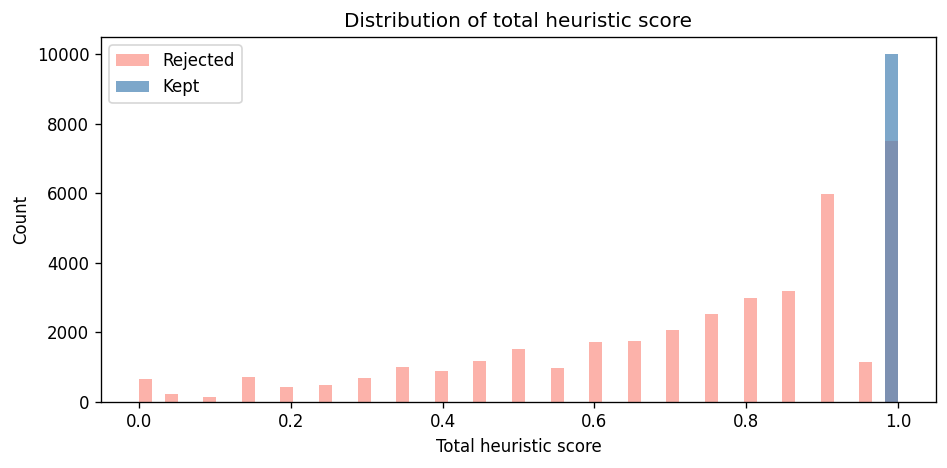

Effective score threshold (min kept): 1.0000
Max rejected score:                   1.0000


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(df["total"].min(), df["total"].max(), 60)
ax.hist(df.loc[~df["kept"], "total"], bins=bins, alpha=0.6, label="Rejected", color="salmon")
ax.hist(df.loc[df["kept"], "total"], bins=bins, alpha=0.7, label="Kept", color="steelblue")
ax.set_xlabel("Total heuristic score")
ax.set_ylabel("Count")
ax.set_title("Distribution of total heuristic score")
ax.legend()
plt.tight_layout()
plt.show()

# Score threshold implied by top-N selection
threshold = df.loc[df["kept"], "total"].min()
print(f"Effective score threshold (min kept): {threshold:.4f}")
print(f"Max rejected score:                   {df.loc[~df['kept'], 'total'].max():.4f}")

## 2. Component score distributions

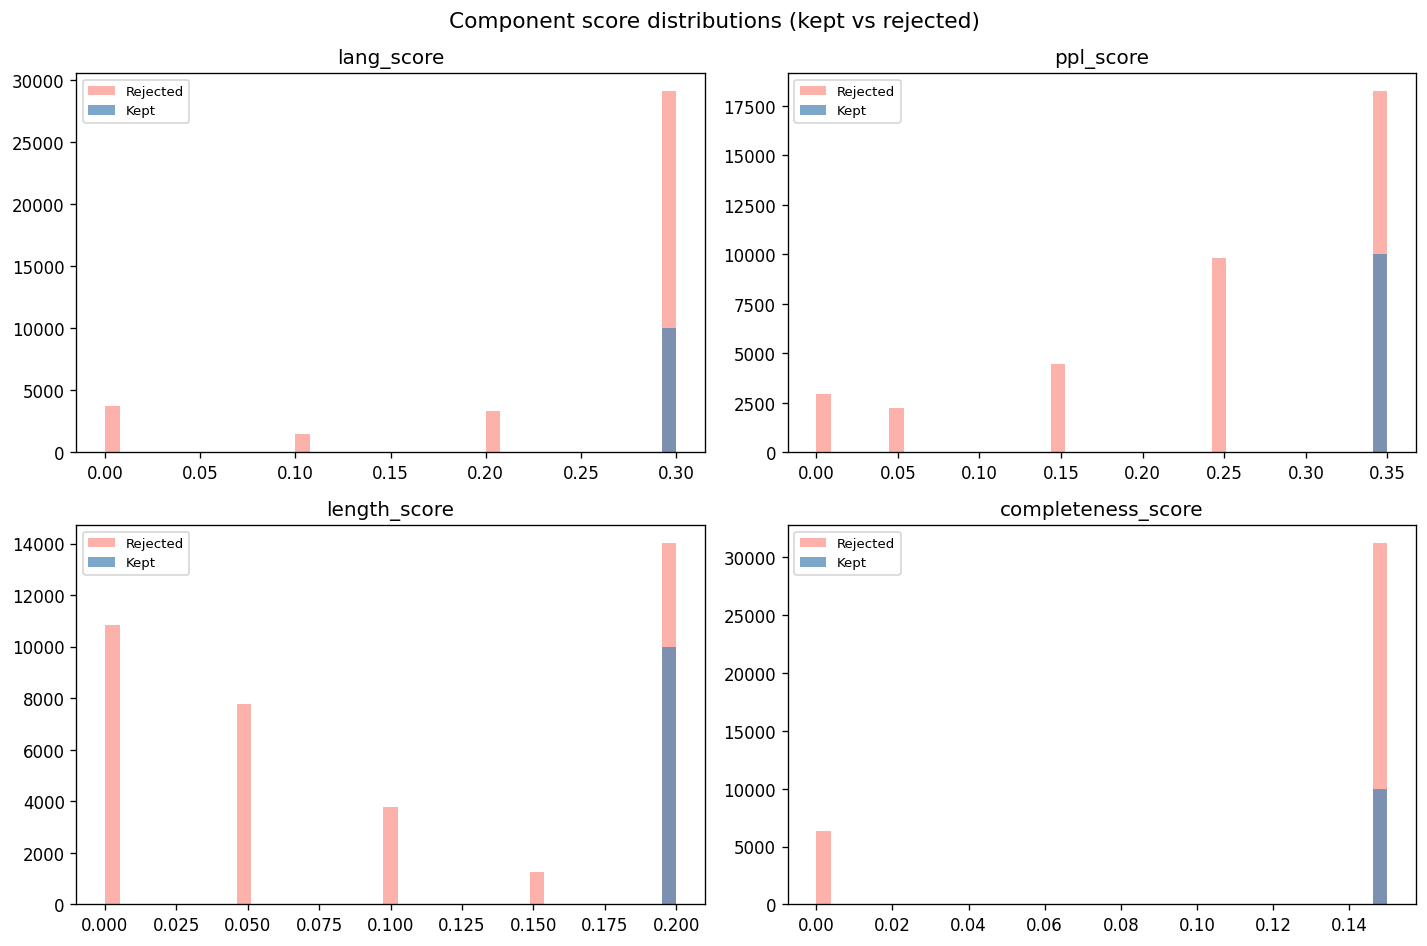

In [3]:
score_cols = ["lang_score", "ppl_score", "length_score", "completeness_score"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, score_cols):
    bins = np.linspace(df[col].min(), df[col].max(), 40)
    ax.hist(df.loc[~df["kept"], col], bins=bins, alpha=0.6, label="Rejected", color="salmon")
    ax.hist(df.loc[df["kept"], col], bins=bins, alpha=0.7, label="Kept", color="steelblue")
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle("Component score distributions (kept vs rejected)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Raw feature distributions

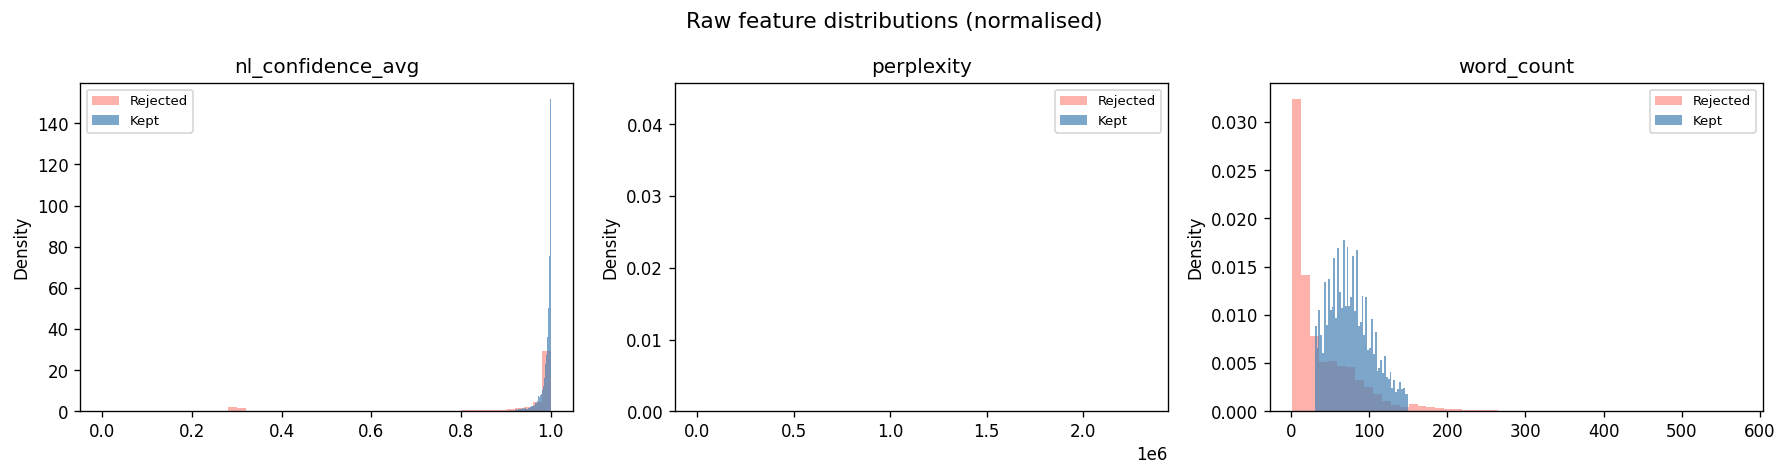

In [4]:
raw_cols = ["nl_confidence_avg", "perplexity", "word_count"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, raw_cols):
    ax.hist(df.loc[~df["kept"], col], bins=50, alpha=0.6, label="Rejected", color="salmon", density=True)
    ax.hist(df.loc[df["kept"], col], bins=50, alpha=0.7, label="Kept", color="steelblue", density=True)
    ax.set_title(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
fig.suptitle("Raw feature distributions (normalised)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. NL confidence: instruction vs output

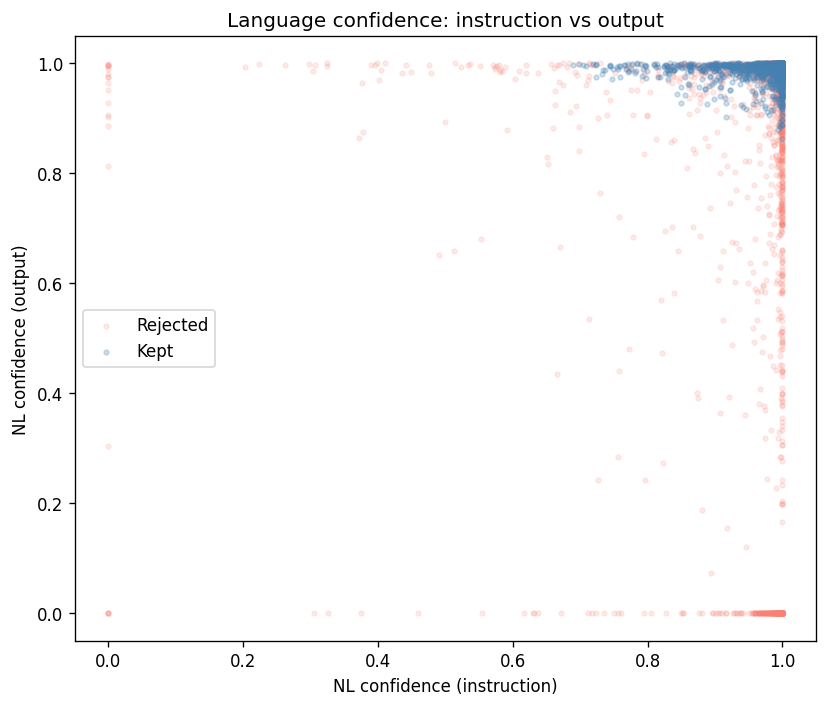

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
sample_rej = df[~df["kept"]].sample(min(3000, (~df["kept"]).sum()), random_state=42)
sample_kept = df[df["kept"]].sample(min(3000, df["kept"].sum()), random_state=42)
ax.scatter(sample_rej["nl_confidence_instruction"], sample_rej["nl_confidence_output"],
           alpha=0.15, s=8, label="Rejected", color="salmon")
ax.scatter(sample_kept["nl_confidence_instruction"], sample_kept["nl_confidence_output"],
           alpha=0.25, s=8, label="Kept", color="steelblue")
ax.set_xlabel("NL confidence (instruction)")
ax.set_ylabel("NL confidence (output)")
ax.set_title("Language confidence: instruction vs output")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Perplexity vs word count

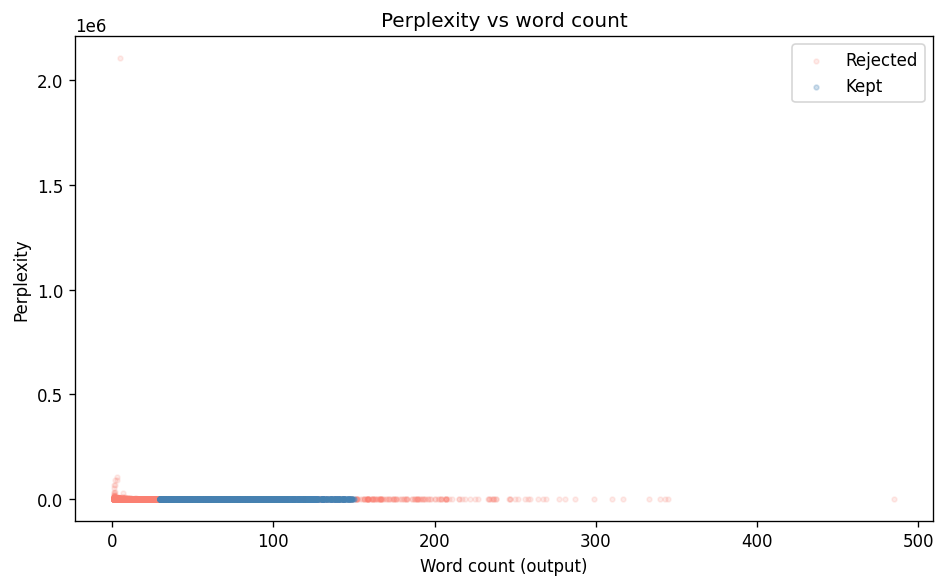

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample_rej["word_count"], sample_rej["perplexity"],
           alpha=0.15, s=8, label="Rejected", color="salmon")
ax.scatter(sample_kept["word_count"], sample_kept["perplexity"],
           alpha=0.25, s=8, label="Kept", color="steelblue")
ax.set_xlabel("Word count (output)")
ax.set_ylabel("Perplexity")
ax.set_title("Perplexity vs word count")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Descriptive statistics

In [7]:
stats_cols = ["total", "nl_confidence_avg", "nl_confidence_instruction",
              "nl_confidence_output", "perplexity", "word_count",
              "lang_score", "ppl_score", "length_score", "completeness_score"]

print("=== KEPT ===")
display(df.loc[df["kept"], stats_cols].describe().round(4))
print("\n=== REJECTED ===")
display(df.loc[~df["kept"], stats_cols].describe().round(4))

=== KEPT ===


,total,nl_confidence_avg,nl_confidence_instruction,nl_confidence_output,perplexity,word_count,lang_score,ppl_score,length_score,completeness_score
count,10000.0,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0,10000.00,10000.0,10000.00
mean,1.0,0.9885,0.9843,0.9903,30.5340,76.4486,0.3,0.35,0.2,0.15
std,0.0,0.0159,0.0391,0.0143,9.6092,27.7125,0.0,0.00,0.0,0.00
min,1.0,0.9000,0.6840,0.8590,3.3000,30.0000,0.3,0.35,0.2,0.15
25%,1.0,0.9860,0.9900,0.9890,23.3000,55.0000,0.3,0.35,0.2,0.15
50%,1.0,0.9950,0.9990,0.9950,30.2000,73.5000,0.3,0.35,0.2,0.15
75%,1.0,0.9980,1.0000,0.9980,37.9000,95.0000,0.3,0.35,0.2,0.15
max,1.0,1.0000,1.0000,1.0000,50.0000,150.0000,0.3,0.35,0.2,0.15



=== REJECTED ===


,total,nl_confidence_avg,nl_confidence_instruction,nl_confidence_output,perplexity,word_count,lang_score,ppl_score,length_score,completeness_score
count,37685.0000,37685.0000,37685.0000,37685.0000,3.768500e+04,37685.0000,37685.0000,37685.0000,37685.0000,37685.0000
mean,0.7331,0.8882,0.9630,0.8562,6.199103e+02,40.4937,0.2535,0.2553,0.0998,0.1245
std,0.2536,0.2151,0.1198,0.2998,1.943502e+04,48.6138,0.0962,0.1150,0.0848,0.0563
min,0.0000,0.0000,0.0000,0.0000,1.000000e+00,1.0000,0.0000,0.0000,0.0000,0.0000
25%,0.6000,0.9240,0.9850,0.9340,3.020000e+01,8.0000,0.3000,0.1500,0.0000,0.1500
50%,0.8000,0.9880,0.9980,0.9910,5.140000e+01,20.0000,0.3000,0.2500,0.1000,0.1500
75%,0.9000,0.9970,1.0000,0.9980,1.021000e+02,60.0000,0.3000,0.3500,0.2000,0.1500
max,1.0000,1.0000,1.0000,1.0000,2.323822e+06,575.0000,0.3000,0.3500,0.2000,0.1500


## 7. Correlation matrix (all scores & features)

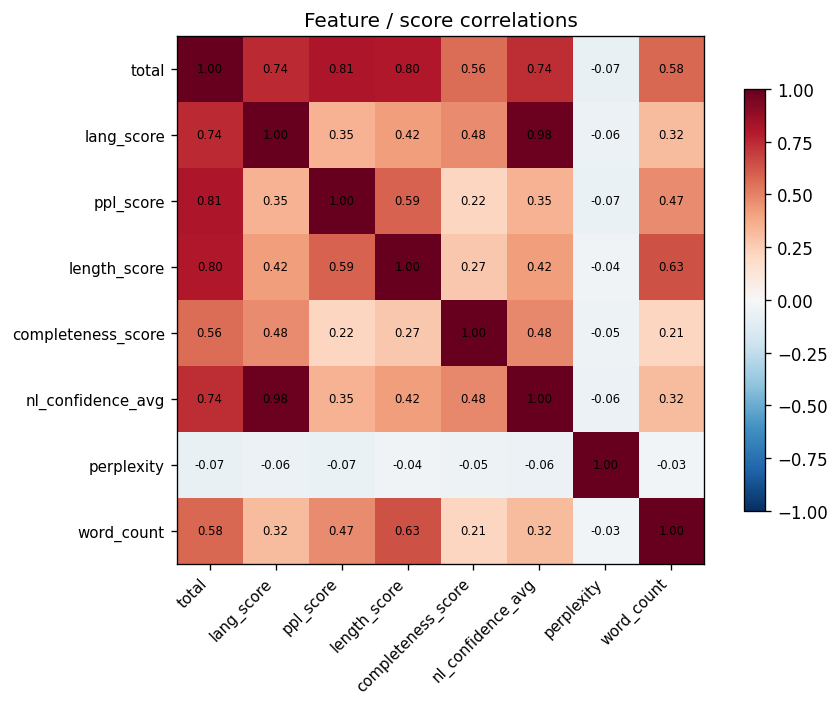

In [8]:
corr_cols = ["total", "lang_score", "ppl_score", "length_score", "completeness_score",
             "nl_confidence_avg", "perplexity", "word_count"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature / score correlations")
plt.tight_layout()
plt.show()

## 8. Sample inspection — borderline examples

Examples near the kept/rejected boundary to sanity-check the split.

In [9]:
df_sorted = df.sort_values("total", ascending=False).reset_index(drop=True)
cutoff_idx = df_sorted[df_sorted["kept"]].index[-1]

print(f"Cutoff index in sorted list: {cutoff_idx}")
print(f"\n--- Last 5 KEPT (just above cutoff) ---")
display(df_sorted.loc[cutoff_idx-4:cutoff_idx,
    ["id", "instruction", "total", "nl_confidence_avg", "perplexity", "word_count", "kept"]])

print(f"\n--- First 5 REJECTED (just below cutoff) ---")
display(df_sorted.loc[cutoff_idx+1:cutoff_idx+5,
    ["id", "instruction", "total", "nl_confidence_avg", "perplexity", "word_count", "kept"]])

Cutoff index in sorted list: 9999

--- Last 5 KEPT (just above cutoff) ---


,id,instruction,total,nl_confidence_avg,perplexity,word_count,kept
9995,27438,Evalueer de positieve en negatieve effecten va...,1.0,0.963,32.6,104,True
9996,27442,Genereer een lijst met innovatieve app-ideeën ...,1.0,0.967,20.9,141,True
9997,27444,Leg uit waarom het resultaat van 6 - 3 = 3 jui...,1.0,0.996,36.8,59,True
9998,27445,Leg uit waarom het resultaat van 4 / 2 = 2 jui...,1.0,0.998,29.2,55,True
9999,27446,Wat is de term voor een onderbreking in de ben...,1.0,0.998,44.8,39,True



--- First 5 REJECTED (just below cutoff) ---


,id,instruction,total,nl_confidence_avg,perplexity,word_count,kept
10000,27447,Analyseer het gedicht en identificeer het gebr...,1.0,0.994,36.9,58,False
10001,27448,Vergelijk de verschillen tussen Google Chrome ...,1.0,0.951,13.2,78,False
10002,27449,Noem vijf redenen waarom de Maan een goede kan...,1.0,0.999,19.6,104,False
10003,27450,Vergelijk en contrasteer de betekenissen van '...,1.0,0.985,30.6,90,False
10004,27453,Maak een lijst van 5 voordelen van het leven o...,1.0,0.994,32.1,79,False


## 9. Worst kept & best rejected examples

In [10]:
print("=== 10 lowest-scoring KEPT examples ===")
display(df[df["kept"]].nsmallest(10, "total")[
    ["id", "instruction", "total", "nl_confidence_avg", "perplexity", "word_count"]])

print("\n=== 10 highest-scoring REJECTED examples ===")
display(df[~df["kept"]].nlargest(10, "total")[
    ["id", "instruction", "total", "nl_confidence_avg", "perplexity", "word_count"]])

=== 10 lowest-scoring KEPT examples ===


,id,instruction,total,nl_confidence_avg,perplexity,word_count
0,1,Geef drie tips om gezond te blijven.,1.0,0.994,22.6,37
1,3,Beschrijf de structuur van een atoom.,1.0,0.996,20.5,57
2,4,Hoe kunnen we luchtvervuiling verminderen?,1.0,0.980,15.0,79
3,5,Doe alsof je een projectmanager bent van een b...,1.0,1.000,17.8,125
4,12,Bespreek de oorzaken van de Grote Depressie,1.0,0.969,23.0,68
5,15,Doe een ethische oplossing voor het probleem v...,1.0,0.998,27.7,81
6,21,Wie is de meest beroemde schilder ter wereld?,1.0,0.974,29.1,76
7,22,Leg het concept van cogging torque uit.,1.0,0.984,24.9,138
8,23,Zoek de kookpunt van water op.,1.0,0.984,21.2,65
9,25,Identificeer de lengtecirkels die Noord- en Zu...,1.0,0.944,16.7,60



=== 10 highest-scoring REJECTED examples ===


,id,instruction,total,nl_confidence_avg,perplexity,word_count
10000,27447,Analyseer het gedicht en identificeer het gebr...,1.0,0.994,36.9,58
10001,27448,Vergelijk de verschillen tussen Google Chrome ...,1.0,0.951,13.2,78
10002,27449,Noem vijf redenen waarom de Maan een goede kan...,1.0,0.999,19.6,104
10003,27450,Vergelijk en contrasteer de betekenissen van '...,1.0,0.985,30.6,90
10004,27453,Maak een lijst van 5 voordelen van het leven o...,1.0,0.994,32.1,79
10005,27454,Leg uit waarom wilde dieren niet als huisdiere...,1.0,0.999,37.2,70
10006,27455,Genereer een kunstconcept gericht op dieren in...,1.0,0.979,28.2,57
10007,27461,Beschrijf de setting en de personages van een ...,1.0,0.997,45.8,84
10008,27463,Beschrijf een creatief project of taak die je ...,1.0,0.996,26.8,95
10009,27464,Train een GPT 3 taalmodel om een realistische ...,1.0,0.999,28.7,77


## 10. What drove rejections the most?

Compare mean component scores between kept and rejected to identify the dominant signal.

,Kept mean,Rejected mean,Δ (kept - rejected),Δ %
lang_score,0.30,0.2535,0.0465,18.3
ppl_score,0.35,0.2553,0.0947,37.1
length_score,0.20,0.0998,0.1002,100.4
completeness_score,0.15,0.1245,0.0255,20.5


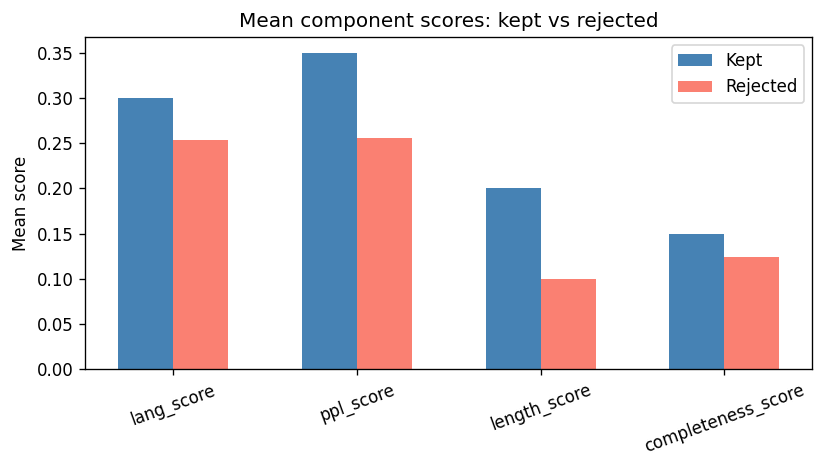

In [11]:
comp_cols = ["lang_score", "ppl_score", "length_score", "completeness_score"]
means = pd.DataFrame({
    "Kept mean": df.loc[df["kept"], comp_cols].mean(),
    "Rejected mean": df.loc[~df["kept"], comp_cols].mean(),
})
means["Δ (kept - rejected)"] = means["Kept mean"] - means["Rejected mean"]
means["Δ %"] = (means["Δ (kept - rejected)"] / means["Rejected mean"] * 100).round(1)
display(means.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(comp_cols))
ax.bar([i - 0.15 for i in x], means["Kept mean"], width=0.3, label="Kept", color="steelblue")
ax.bar([i + 0.15 for i in x], means["Rejected mean"], width=0.3, label="Rejected", color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(comp_cols, rotation=20)
ax.set_ylabel("Mean score")
ax.set_title("Mean component scores: kept vs rejected")
ax.legend()
plt.tight_layout()
plt.show()